In [1]:
import os
import glob

import ants

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import nibabel as nib

import SimpleITK as sitk

from skimage.transform import resize

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [4]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:
        nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


##  SOOP (FLAIR, ADC & masks)
Original Size: (281, 352, 352)\
1. no resampling since they already have isotropic resolution (2, 2, 2)
2. PAD to (352, 352, 352)
3. Resize to (128, 128, 128)
4. Register it to histogram matched MNI

In [16]:
soop_flair_unprocessed_folder = ROOT_DIR+"/datasets/soop_flair_skullstrip/"
soop_adc_unprocessed_folder = ROOT_DIR+"/datasets/soop_adc_skullstrip/"
soop_masks_acute_unprocessed_folder = ROOT_DIR+"/datasets/soop_masks_acute/"
soop_masks_chronic_unprocessed_folder = ROOT_DIR+"/datasets/soop_masks_chronic/"


soop_flair_resized_folder = ROOT_DIR+"/datasets/soop_flair_resized/"
os.makedirs(soop_flair_resized_folder, exist_ok=True)
soop_adc_resized_folder = ROOT_DIR+"/datasets/soop_adc_resized/"
os.makedirs(soop_adc_resized_folder, exist_ok=True)
soop_masks_acute_resized_folder = ROOT_DIR+"/datasets/soop_masks_acute_resized/"
os.makedirs(soop_masks_acute_resized_folder, exist_ok=True)
soop_masks_chronic_resized_folder = ROOT_DIR+"/datasets/soop_masks_chronic_resized/"
os.makedirs(soop_masks_chronic_resized_folder, exist_ok=True)


soop_flair_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/flair_registered/"
os.makedirs(soop_flair_final_output_folder_registered, exist_ok=True)
soop_adc_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/adc_registered/"
os.makedirs(soop_adc_final_output_folder_registered, exist_ok=True)
soop_masks_acute_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_acute_registered/"
os.makedirs(soop_masks_acute_final_output_folder_registered, exist_ok=True)
soop_masks_chronic_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_chronic_registered/"
os.makedirs(soop_masks_chronic_final_output_folder_registered, exist_ok=True)

#### FLAIR

Image 1 shape: (1024, 172, 1024)
Image 2 shape: (219, 400, 400)
Image 3 shape: (400, 400, 28)
Image 4 shape: (1024, 220, 1024)


<Figure size 640x480 with 0 Axes>

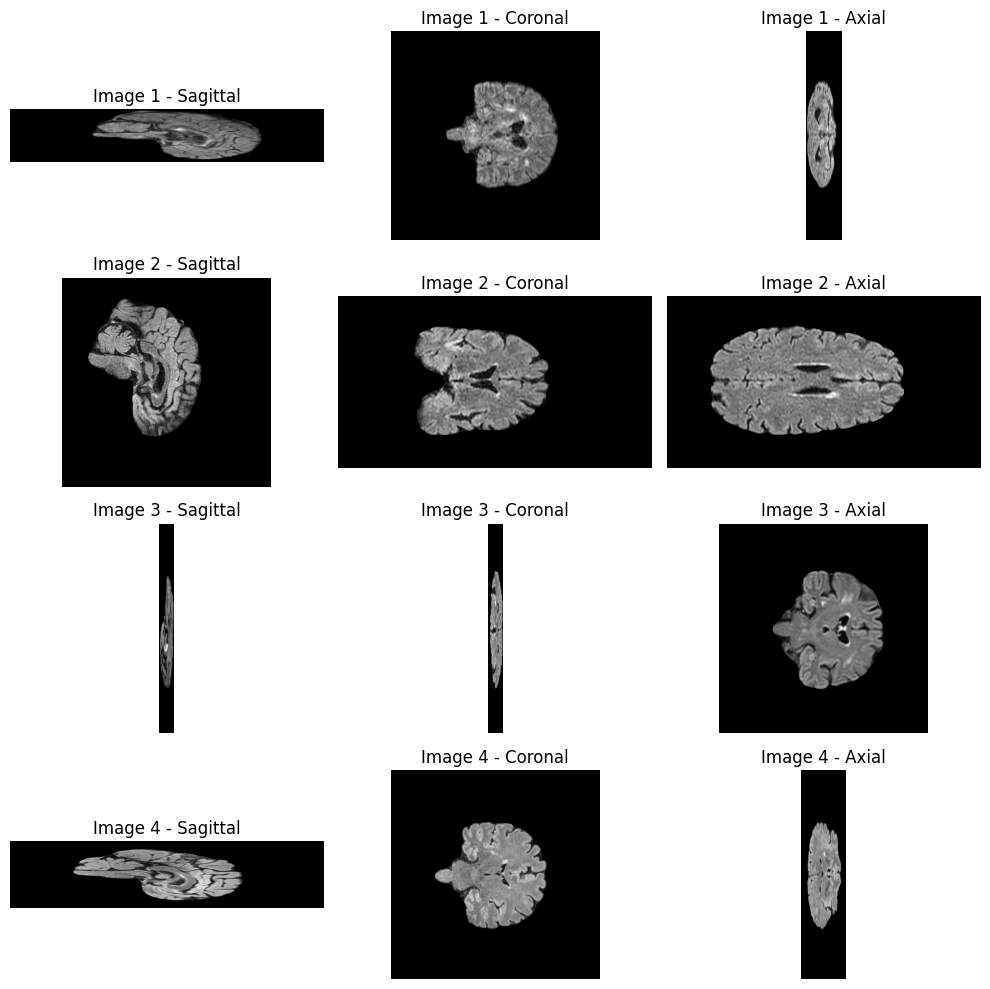

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [7]:
""" for image_path in tqdm(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(soop_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path) """

' for image_path in tqdm(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))):\n    itk_image = sitk.ReadImage(image_path)\n    resampled_image = resample_img(itk_image)\n    output_path = os.path.join(soop_flair_resized_folder, os.path.basename(image_path))\n    sitk.WriteImage(resampled_image, output_path) '

In [8]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_image_resample(image_path, output_folder):
    try:
        itk_image = sitk.ReadImage(image_path)
        resampled_image = resample_img(itk_image)
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        sitk.WriteImage(resampled_image, output_path)
        return image_path
    except Exception as e:
        return f"Error with {image_path}: {e}"



image_paths = glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample, path, soop_flair_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()


Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [02:53<00:00,  9.86it/s]


Image 1 shape: (251, 172, 251)
Image 2 shape: (197, 250, 250)
Image 3 shape: (230, 230, 168)
Image 4 shape: (253, 220, 253)


<Figure size 640x480 with 0 Axes>

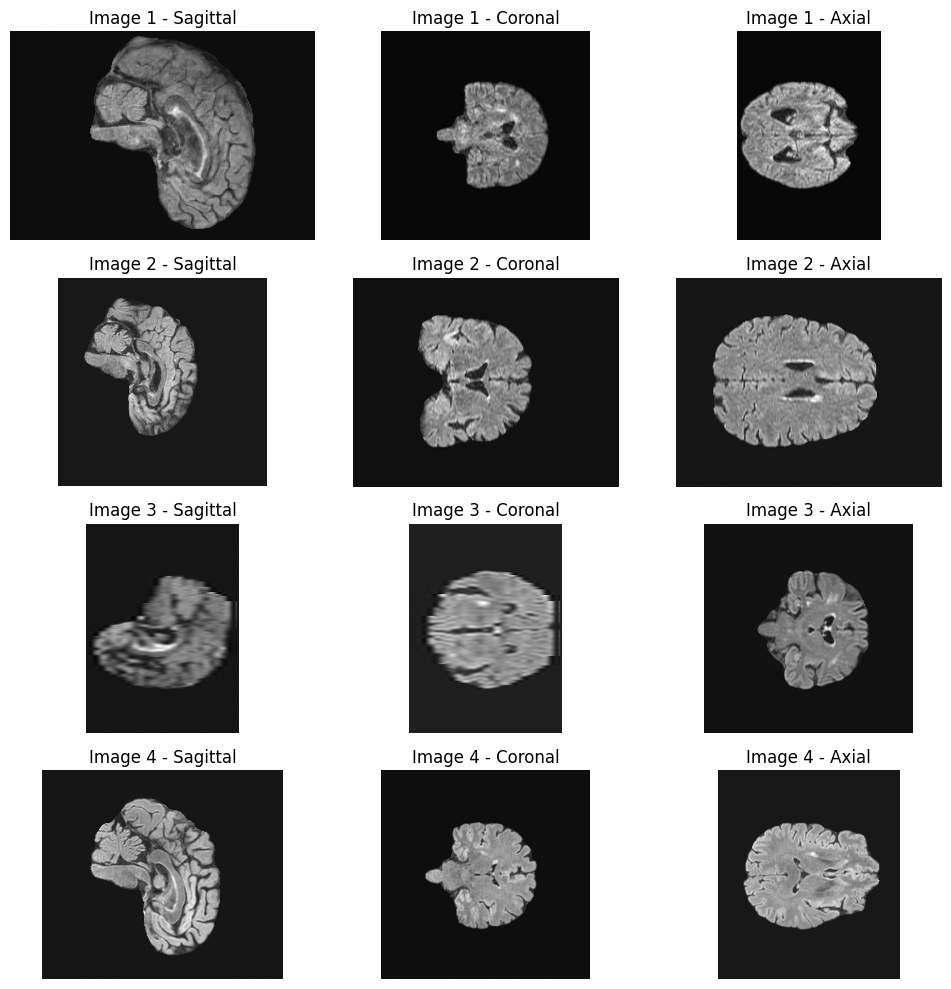

In [9]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Auto-orient SOOP FLAIR images to RAS orientation
def process_image_orient(image_path, output_folder):
    # Read the image with SimpleITK
    itk_image = sitk.ReadImage(image_path)
    
    # Orient to RAS (Right-Anterior-Superior)
    oriented_image = sitk.DICOMOrient(itk_image, 'RAS')
    
    # Overwrite the original file with the oriented version
    sitk.WriteImage(oriented_image, image_path)



image_paths = glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_orient, path, soop_flair_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()
print("All SOOP FLAIR images have been oriented to RAS direction.")

Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [00:55<00:00, 30.73it/s]

All SOOP FLAIR images have been oriented to RAS direction.


Image 1 shape: (251, 172, 251)
Image 2 shape: (197, 250, 250)
Image 3 shape: (230, 168, 230)
Image 4 shape: (253, 220, 253)


<Figure size 640x480 with 0 Axes>

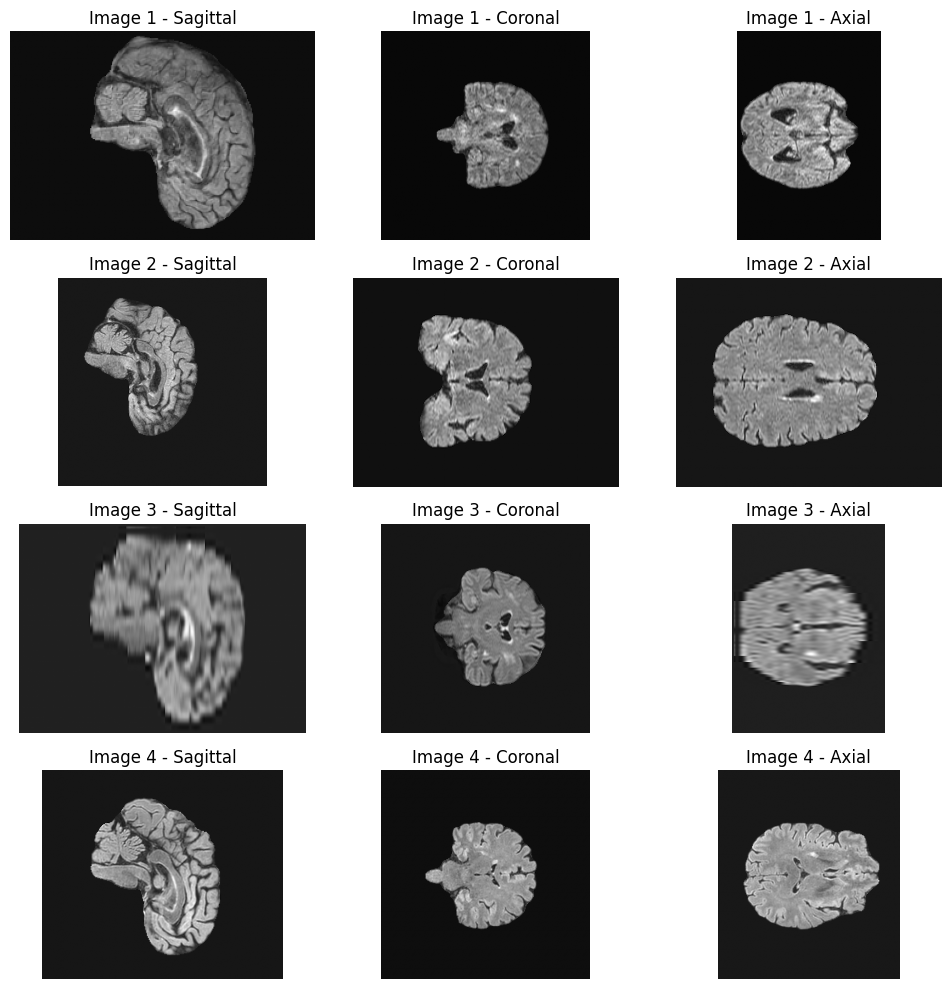

In [11]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [36]:
# Registration
def process_image_register(image_path, output_folder):
    print(f"image path: {image_path}")
    print(f"image basename: {os.path.basename(image_path)}")
    print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")
    moving_image = ants.image_read(image_path)
    fixed_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz")

    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # Save the registered image
    ants.image_write(registration['warpedmovout'], os.path.join(output_folder, os.path.basename(image_path)))

    #print(f"Registered {moving_file} and saved to {output_filepath}")


image_paths = glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, soop_flair_final_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1673_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-207_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1620_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1568_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-909_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1328_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-598_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-573_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-587_FLAIR.nii.gz
image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-504_FLAIR.n

Processing images:   0%|                                                                                                                         | 0/1715 [00:00<?, ?it/s]

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-962_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1348_FLAIR.nii.gz

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-124_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1099_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-902_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1689_FLAIR.nii.gz

image basename: sub-1673_FLAIR.nii.gz



image basename: sub-1620_FLAIR.nii.gz
image basename: sub-1568_FLAIR.nii.gz




image basename: sub-207_FLAIR.nii.gz


image basename: sub-909_FLAIR.nii.gz

image basename: sub-1328_FLAIR.nii.gz

image basename: sub-598_FLAIR.nii.gz



image basename: sub-573_FLAIR.nii.gzimage basename: sub-587_FLAIR.nii.gz
image basename: sub-504_FLAIR.nii.gzimage b

Processing images:   0%|                                                                                                               | 1/1715 [00:04<2:22:19,  4.98s/it]

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1236_FLAIR.nii.gz
image basename: sub-1236_FLAIR.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/flair_registered/sub-1236_FLAIR.nii.gz


...

Processing images:  98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▋  | 1679/1715 [05:13<00:09,  3.70it/s]

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1360_FLAIR.nii.gz
image basename: sub-1360_FLAIR.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/flair_registered/sub-1360_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-445_FLAIR.nii.gz

image basename: sub-445_FLAIR.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/flair_registered/sub-445_FLAIR.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1418_FLAIR.nii.gz

image basename: sub-1418_FLAIR.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/flair_registered/sub-1418_FLAIR.nii.gz


Processing images:  98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 1682/1715 [05:14<00:07,  4.21it/s]

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1687_FLAIR.nii.gz
image basename: sub-1687_FLAIR.nii.gz
image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_flair_resized/sub-1623_FLAIR.nii.gzoutput path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/flair_registered/sub-1687_FLAIR.nii.gz

image basename: sub-1623_FLAIR.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/flair_registered/sub-1623_FLAIR.nii.gz


Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [05:18<00:00,  5.38it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)
Image 5 shape: (128, 128, 128)
Image 6 shape: (128, 128, 128)
Image 7 shape: (128, 128, 128)
Image 8 shape: (128, 128, 128)
Image 9 shape: (128, 128, 128)
Image 10 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

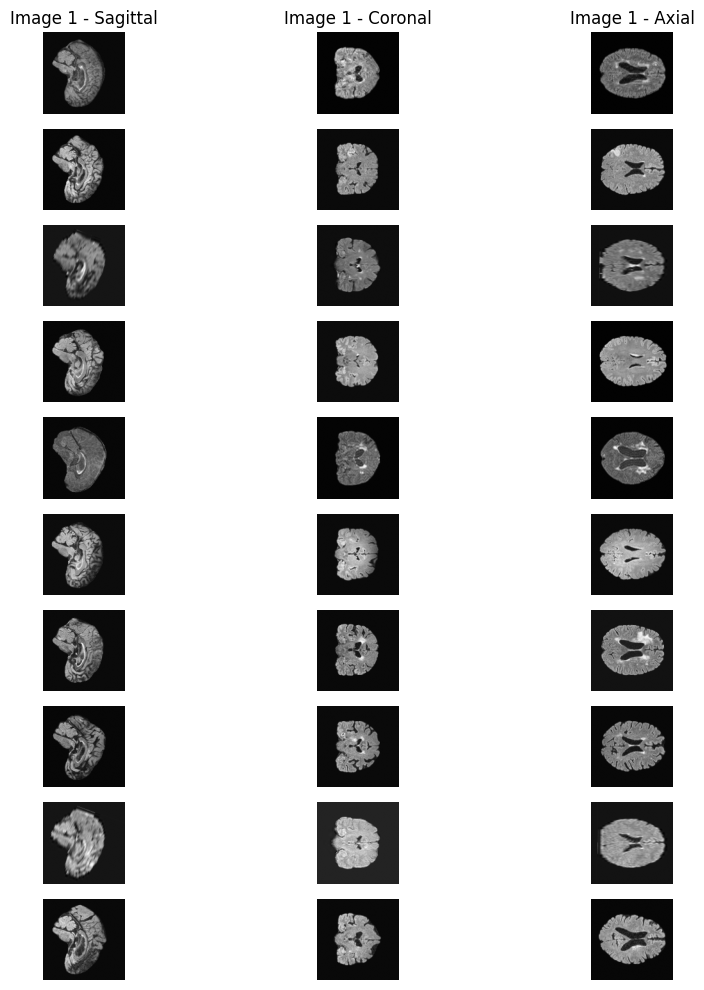

In [13]:
# Get the first 10 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_final_output_folder_registered, "*.nii.gz")))[:10]

# Plot the images
plt.suptitle("SOOP registered Images 1mm3")
fig, axes = plt.subplots(10, 3, figsize=(10, 10))

for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].axis("off")

    if i==0:
        axes[i, 0].set_title(f"Image {i+1} - Sagittal")
        axes[i, 1].set_title(f"Image {i+1} - Coronal")
        axes[i, 2].set_title(f"Image {i+1} - Axial")

plt.tight_layout()
plt.show()

#### ADC

Image 1 sub-1000_rec-ADC_dwi.nii.gz shape: (224, 224, 25)
Image 2 sub-1001_rec-ADC_dwi.nii.gz shape: (224, 224, 26)
Image 3 sub-1002_rec-ADC_dwi.nii.gz shape: (320, 320, 25)
Image 4 sub-1003_rec-ADC_dwi.nii.gz shape: (480, 480, 25)


<Figure size 640x480 with 0 Axes>

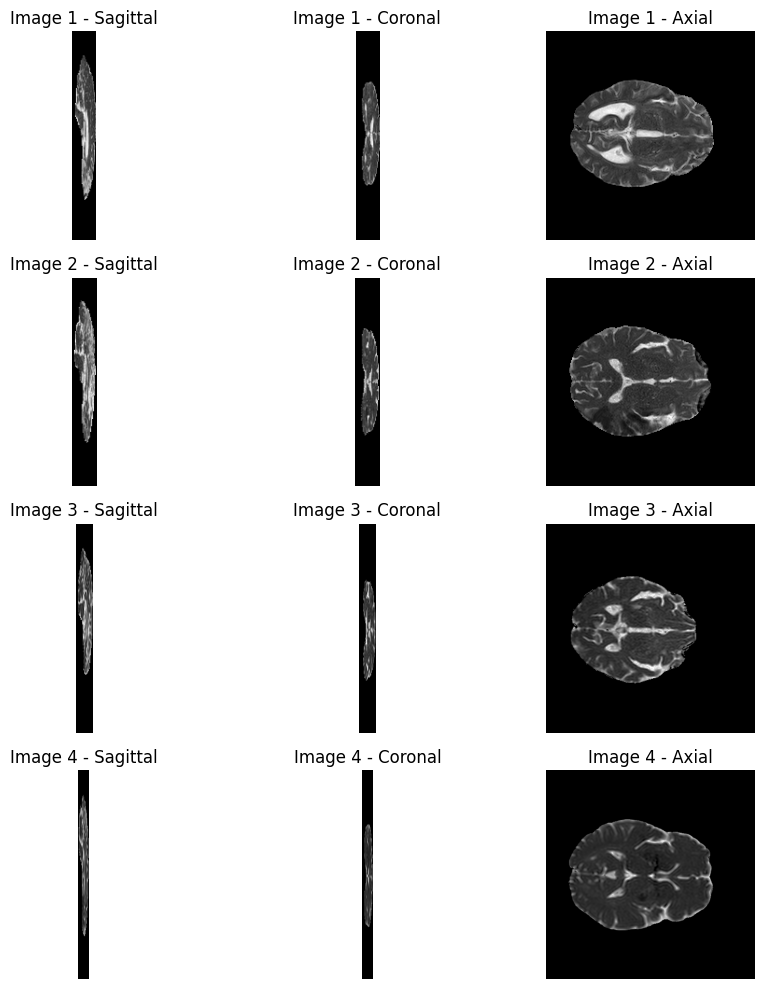

In [18]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_adc_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} {os.path.basename(image_path)} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Image 1 sub-1000_space-TRACE_desc-lesionAcute_mask.nii.gz shape: (224, 224, 25)
Image 2 sub-1001_space-TRACE_desc-lesionAcute_mask.nii.gz shape: (224, 224, 26)
Image 3 sub-1003_space-TRACE_desc-lesionAcute_mask.nii.gz shape: (480, 480, 25)
Image 4 sub-1004_space-TRACE_desc-lesionAcute_mask.nii.gz shape: (256, 256, 26)


<Figure size 640x480 with 0 Axes>

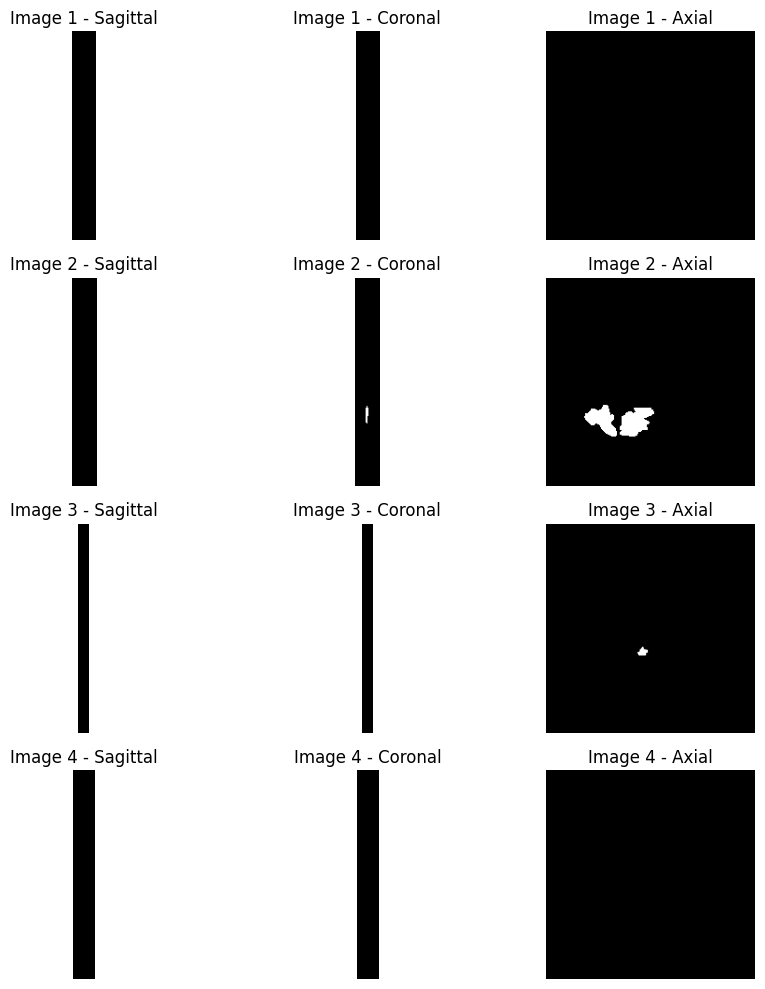

In [19]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_masks_acute_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} {os.path.basename(image_path)} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
""" for image_path in tqdm(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(soop_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path) """

In [21]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_image_resample(image_path, output_folder):
    try:
        itk_image = sitk.ReadImage(image_path)
        resampled_image = resample_img(itk_image)
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        sitk.WriteImage(resampled_image, output_path)
        return image_path
    except Exception as e:
        return f"Error with {image_path}: {e}"


# resample adc images
image_paths = glob.glob(os.path.join(soop_adc_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample, path, soop_adc_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

# resample acute masks
image_paths = glob.glob(os.path.join(soop_masks_acute_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample, path, soop_masks_acute_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

# resample chronic masks
image_paths = glob.glob(os.path.join(soop_masks_chronic_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample, path, soop_masks_chronic_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()


Processing images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:04<00:00, 49.78it/s]


Image 1 shape: (248, 248, 150)
Image 2 shape: (248, 248, 156)
Image 3 shape: (260, 260, 150)
Image 4 shape: (251, 251, 150)


<Figure size 640x480 with 0 Axes>

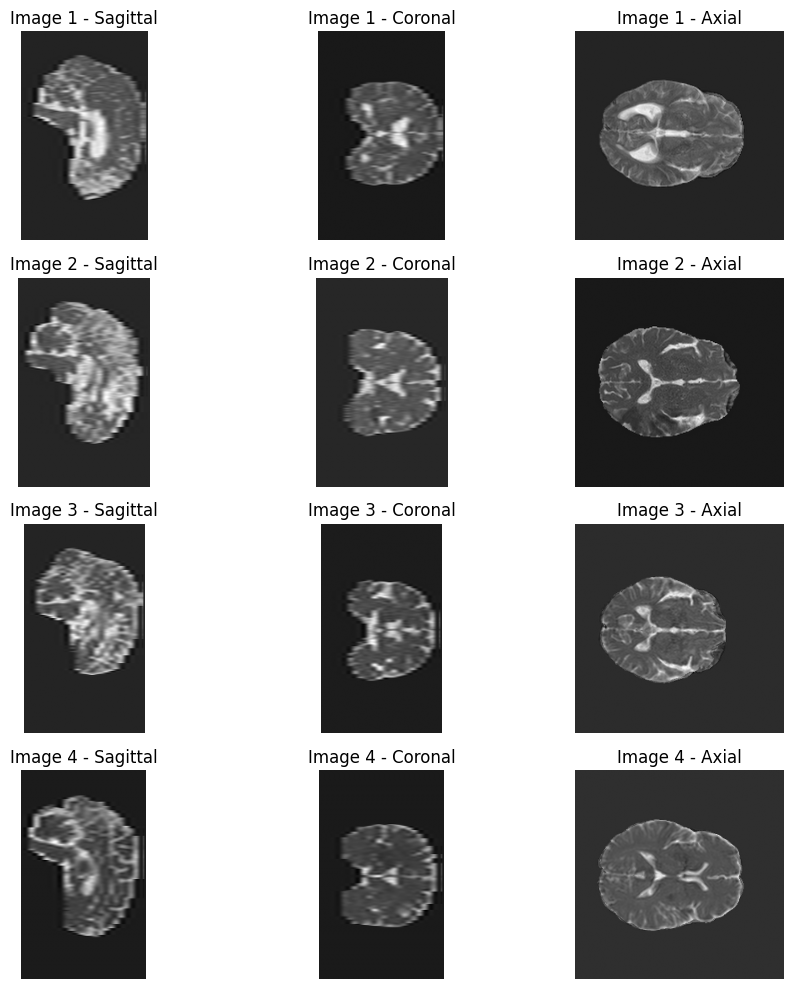

In [22]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [29]:

# Set first 4 and last 4 axial slices to zero for all mask images
all_mask_paths = glob.glob(os.path.join(soop_masks_acute_resized_folder, "*.nii.gz"))

for image_path in tqdm(all_mask_paths, desc="Processing acute masks"):
    # Load the image
    img = nib.load(image_path)
    data = img.get_fdata()
    
    # Set first 4 and last 4 axial slices to zero
    data[:, :, :5] = 0.0
    data[:, :, -5:] = 0.0
    
    # Save the modified image
    new_img = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(new_img, image_path)

Processing acute masks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1451/1451 [02:07<00:00, 11.37it/s]


In [30]:

# Set first 4 and last 4 axial slices to zero for all mask images
all_mask_paths = glob.glob(os.path.join(soop_masks_chronic_resized_folder, "*.nii.gz"))

for image_path in tqdm(all_mask_paths, desc="Processing chronic masks"):
    # Load the image
    img = nib.load(image_path)
    data = img.get_fdata()
    
    # Set first 4 and last 4 axial slices to zero
    data[:, :, :5] = 0.0
    data[:, :, -5:] = 0.0
    
    # Save the modified image
    new_img = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(new_img, image_path)

Processing chronic masks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:17<00:00, 11.57it/s]


In [31]:
# Registration
def process_image_register(image_path, output_folder):
    print(f"image path: {image_path}")
    print(f"image basename: {os.path.basename(image_path)}")
    print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")

    moving_image = ants.image_read(image_path)
    fixed_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz")

    masks_acute_paths = glob.glob(os.path.join(soop_masks_acute_resized_folder, "*.nii.gz"))
    masks_chronic_paths = glob.glob(os.path.join(soop_masks_chronic_resized_folder, "*.nii.gz"))

    subject = os.path.basename(image_path).split('_')[0]


    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # if acute or chronic mask exists for this subject, register it too using the same transform
    if subject+"_space-TRACE_desc-lesionAcute_mask.nii.gz" in [os.path.basename(p) for p in masks_acute_paths]:
        print(f"found acute mask for subject {subject}")
        mask_image = ants.image_read(soop_masks_acute_resized_folder+subject+"_space-TRACE_desc-lesionAcute_mask.nii.gz")
        transform = registration['fwdtransforms']
        mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
        mask_moved.to_file(soop_masks_acute_final_output_folder_registered+subject+"_space-TRACE_desc-lesionAcute_mask.nii.gz")
    
    if subject+"_space-TRACE_desc-lesionChronic_mask.nii.gz" in [os.path.basename(p) for p in masks_chronic_paths]:
        print(f"found chronic mask for subject {subject}")
        mask_image = ants.image_read(soop_masks_chronic_resized_folder+subject+"_space-TRACE_desc-lesionChronic_mask.nii.gz")
        transform = registration['fwdtransforms']
        mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
        mask_moved.to_file(soop_masks_chronic_final_output_folder_registered+subject+"_space-TRACE_desc-lesionChronic_mask.nii.gz")

    # Save the registered image
    ants.image_write(registration['warpedmovout'], os.path.join(output_folder, os.path.basename(image_path)))



image_paths = glob.glob(os.path.join(soop_adc_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, soop_adc_final_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

image path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-258_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-333_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-789_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-74_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-373_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-1534_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-391_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-173_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soop_adc_resized/sub-501_rec-ADC_dwi.nii.gzimage path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/soo

Processing images:   0%|                                                                                                                         | 0/1715 [00:00<?, ?it/s]



image basename: sub-789_rec-ADC_dwi.nii.gz
image basename: sub-333_rec-ADC_dwi.nii.gz
image basename: sub-74_rec-ADC_dwi.nii.gzimage basename: sub-391_rec-ADC_dwi.nii.gzimage basename: sub-373_rec-ADC_dwi.nii.gzimage basename: sub-173_rec-ADC_dwi.nii.gz
image basename: sub-501_rec-ADC_dwi.nii.gzimage basename: sub-897_rec-ADC_dwi.nii.gzimage basename: sub-3_rec-ADC_dwi.nii.gz
image basename: sub-1534_rec-ADC_dwi.nii.gzimage basename: sub-507_rec-ADC_dwi.nii.gz
image basename: sub-1187_rec-ADC_dwi.nii.gz




output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/adc_registered/sub-258_rec-ADC_dwi.nii.gz

output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/adc_registered/sub-789_rec-ADC_dwi.nii.gz

output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/adc_registered/sub-333_rec-ADC_dwi.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/adc_regis

Processing images:   0%|                                                                                                               | 1/1715 [00:03<1:53:22,  3.97s/it]


image basename: sub-58_rec-ADC_dwi.nii.gz
output path: /bettik/PROJECTS/pr-gin5_aini/fehrdelt//datasets/final_soop_dataset_small/adc_registered/sub-58_rec-ADC_dwi.nii.gz


...

Processing images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 1703/1715 [05:05<00:02,  4.46it/s]

found acute mask for subject sub-1407
found acute mask for subject sub-313
found acute mask for subject sub-961
found acute mask for subject sub-188
found acute mask for subject sub-1352
found acute mask for subject sub-760


Processing images:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 1706/1715 [05:05<00:01,  7.73it/s]

found chronic mask for subject sub-1407
found chronic mask for subject sub-961


Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [05:06<00:00,  5.60it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

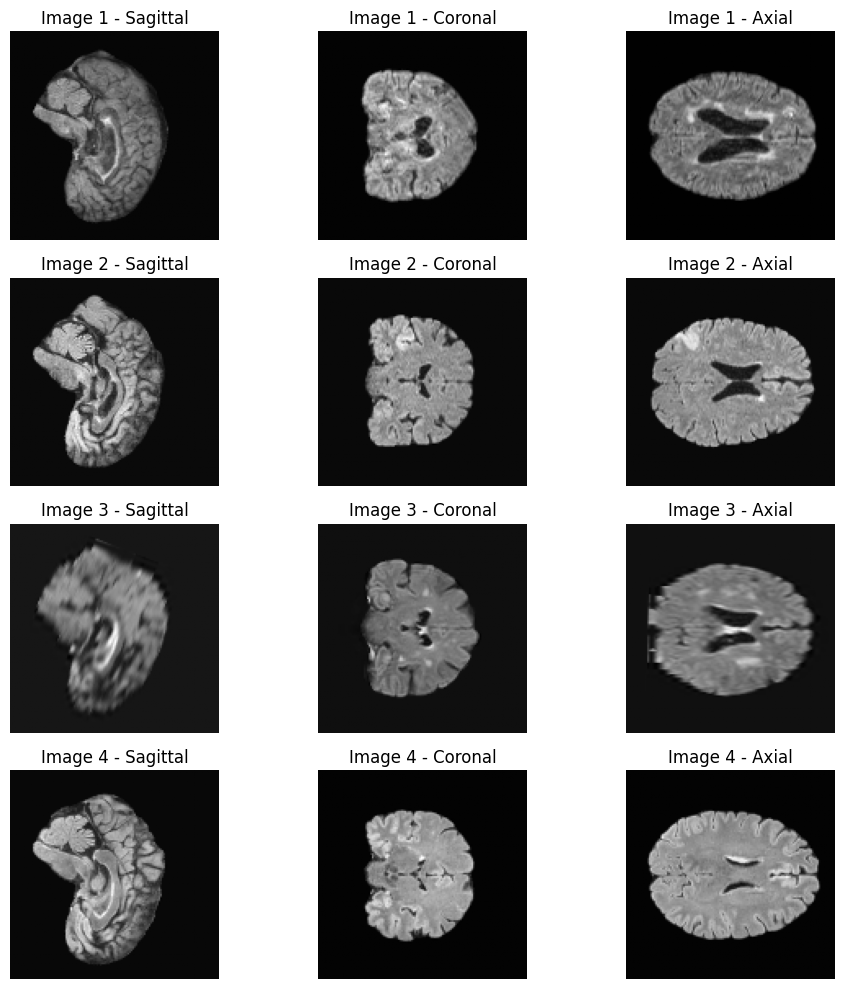

In [37]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("SOOP flair registered")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

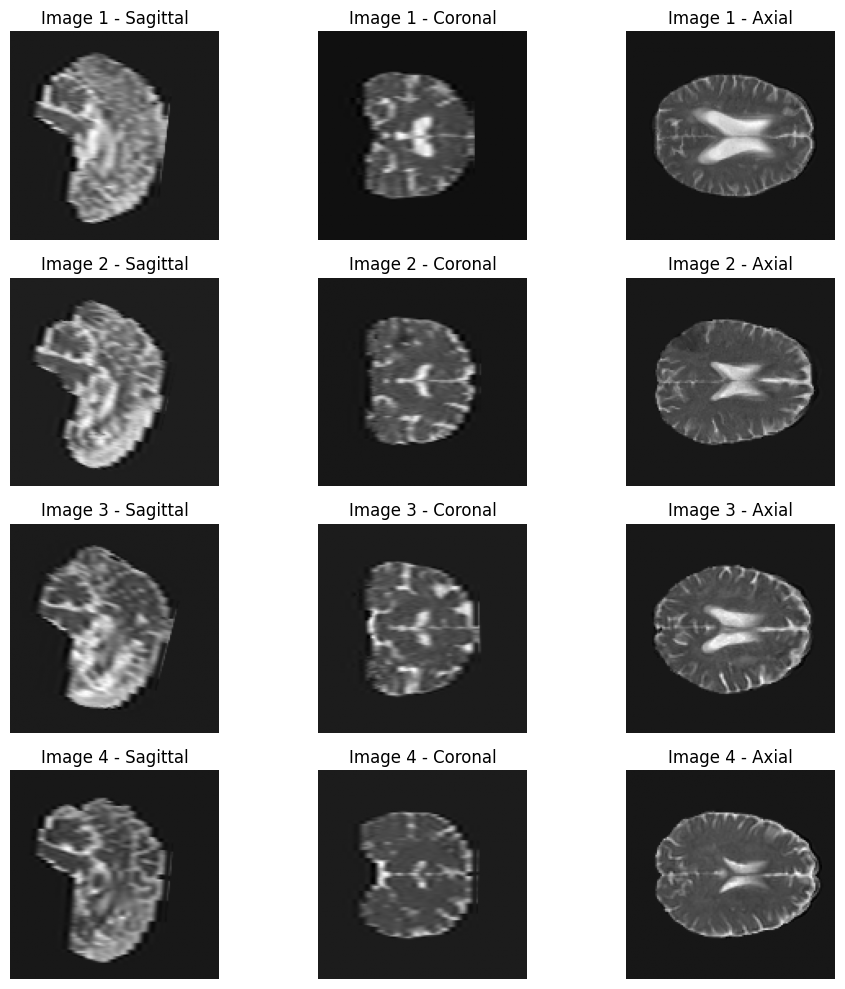

In [38]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_adc_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("SOOP adc registered")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

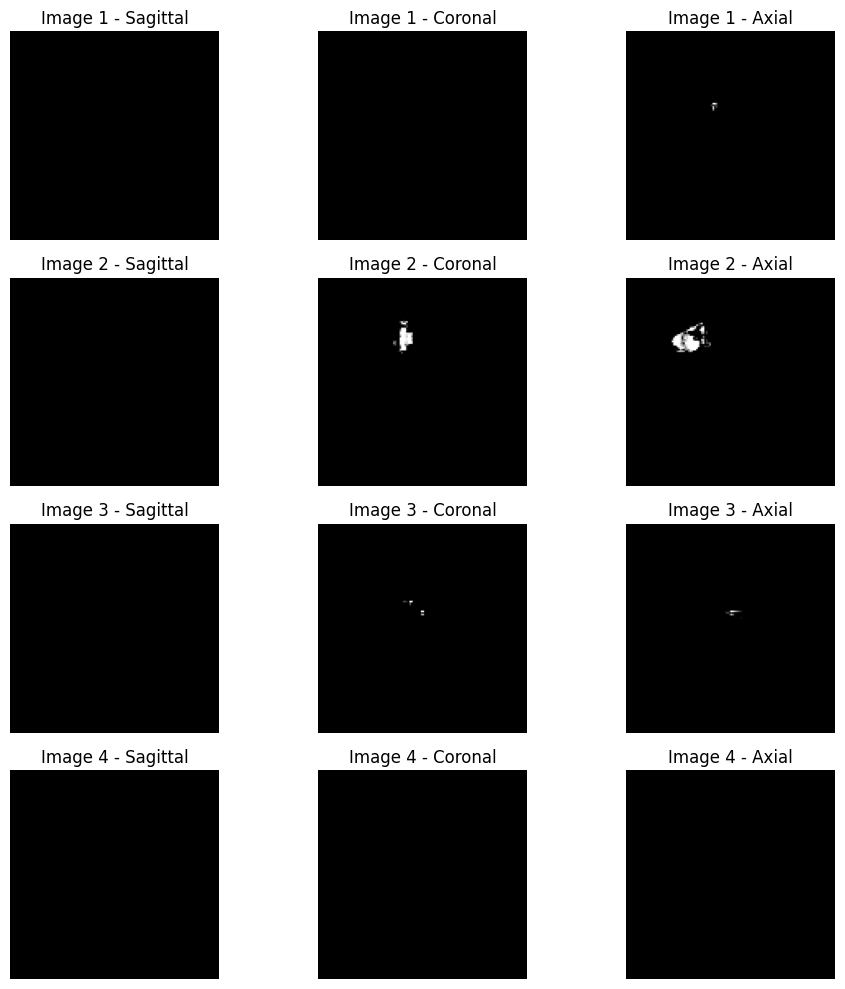

In [39]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_masks_acute_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("SOOP masks acute registered")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Error loading mask image for flair 3: No such file or no access: '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_soop_dataset_small/masks_acute_registered/sub-1002_space-TRACE_desc-lesionAcute_mask.nii.gz'
Error loading mask image for flair 9: No such file or no access: '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_soop_dataset_small/masks_acute_registered/sub-1008_space-TRACE_desc-lesionAcute_mask.nii.gz'


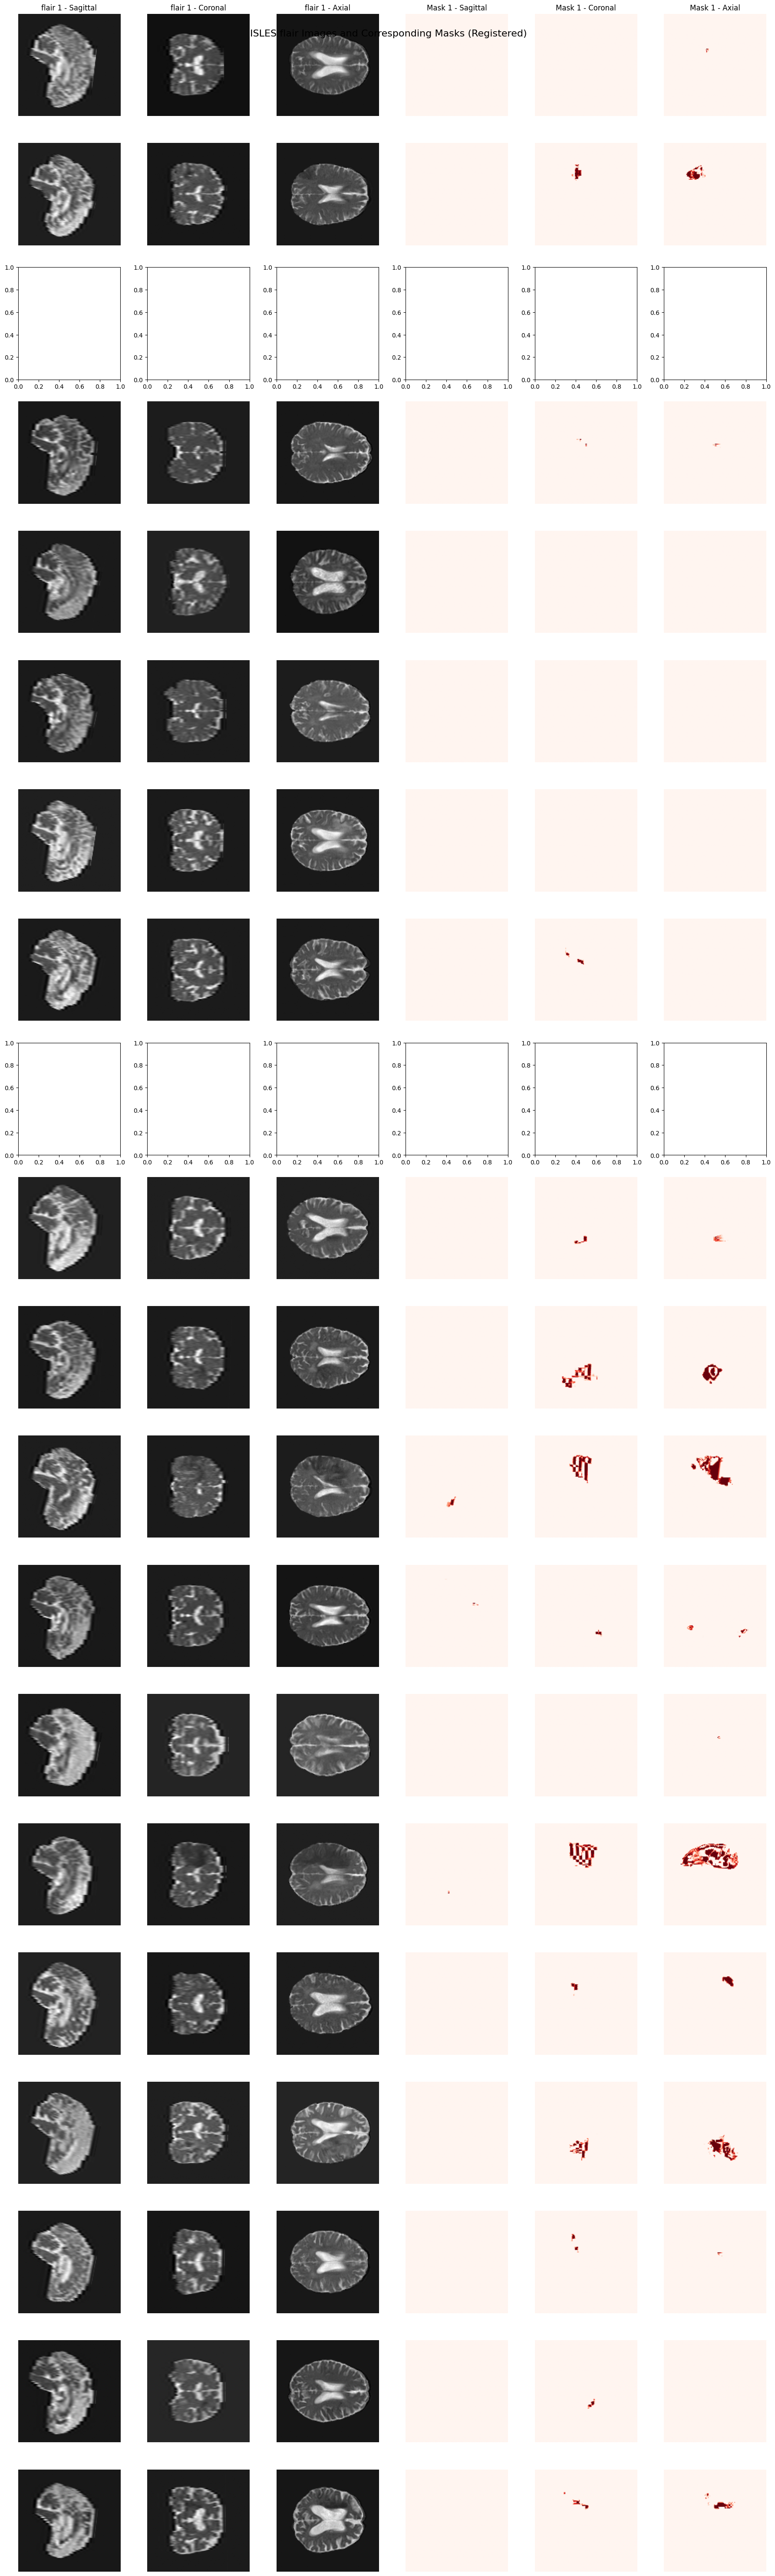

In [41]:
# Get sorted file paths for both flair images and masks
flair_paths = sorted(glob.glob(os.path.join(soop_adc_final_output_folder_registered, "*.nii.gz")))

# Take first 10 pairs for visualization
num_pairs = min(20, len(flair_paths))

fig, axes = plt.subplots(num_pairs, 6, figsize=(18, 3*num_pairs))
plt.suptitle("ISLES flair Images and Corresponding Masks (Registered)", fontsize=16)

for i in range(num_pairs):
    # Load flair image and mask
    flair_img = nib.load(flair_paths[i]).get_fdata()
    try:
        mask_img = nib.load(soop_masks_acute_final_output_folder_registered+os.path.basename(flair_paths[i]).split("_")[0] + "_space-TRACE_desc-lesionAcute_mask.nii.gz").get_fdata()
    except Exception as e:
        print(f"Error loading mask image for flair {i+1}: {e}")
        continue

    # Get middle slices
    mid_slice = flair_img.shape[2] // 2
    flair_axial = flair_img[:, :, mid_slice]
    mask_axial = mask_img[:, :, mid_slice]
    
    mid_slice_sag = flair_img.shape[0] // 2
    flair_sagittal = flair_img[mid_slice_sag, :, :]
    mask_sagittal = mask_img[mid_slice_sag, :, :]
    
    mid_slice_cor = flair_img.shape[1] // 2
    flair_coronal = flair_img[:, mid_slice_cor, :]
    mask_coronal = mask_img[:, mid_slice_cor, :]
    
    # Plot flair sagittal
    axes[i, 0].imshow(flair_sagittal, cmap="gray")
    axes[i, 0].set_title(f"flair {i+1} - Sagittal" if i == 0 else "")
    axes[i, 0].axis("off")
    
    # Plot flair coronal
    axes[i, 1].imshow(flair_coronal, cmap="gray")
    axes[i, 1].set_title(f"flair {i+1} - Coronal" if i == 0 else "")
    axes[i, 1].axis("off")
    
    # Plot flair axial
    axes[i, 2].imshow(flair_axial, cmap="gray")
    axes[i, 2].set_title(f"flair {i+1} - Axial" if i == 0 else "")
    axes[i, 2].axis("off")
    
    # Plot Mask sagittal
    axes[i, 3].imshow(mask_sagittal, cmap="Reds")
    axes[i, 3].set_title(f"Mask {i+1} - Sagittal" if i == 0 else "")
    axes[i, 3].axis("off")
    
    # Plot Mask coronal
    axes[i, 4].imshow(mask_coronal, cmap="Reds")
    axes[i, 4].set_title(f"Mask {i+1} - Coronal" if i == 0 else "")
    axes[i, 4].axis("off")
    
    # Plot Mask axial
    axes[i, 5].imshow(mask_axial, cmap="Reds")
    axes[i, 5].set_title(f"Mask {i+1} - Axial" if i == 0 else "")
    axes[i, 5].axis("off")

plt.tight_layout()
plt.show()